In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\19012\anaconda3\envs\yelp_nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def find_project_root(start_dir: Path) -> Path:
    required = Path("data") / "processed" / "train_data.csv"
    current = start_dir.resolve()

    for _ in range(10):
        if (current / required).exists():
            return current
        if current.parent == current:
            break
        current = current.parent

    raise FileNotFoundError(
        "Could not locate project root containing data/processed/train_data.csv. "
        "Please run this notebook from within the project directory."
    )

project_root = find_project_root(Path.cwd())

train_path = project_root / "data" / "processed" / "train_data.csv"
val_path = project_root / "data" / "processed" / "val_data.csv"
test_path = project_root / "data" / "processed" / "test_data.csv"

model_dir = project_root / "s1_baseline_models" / "baseline_embedding"
result_dir = project_root / "s1_baseline_results" / "baseline_embedding"
cache_dir = result_dir / "cache"

model_dir.mkdir(parents=True, exist_ok=True)
result_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Train path:", train_path)
print("Val path:", val_path)
print("Test path:", test_path)
print("Model dir:", model_dir)
print("Result dir:", result_dir)
print("Cache dir:", cache_dir)

Project root: D:\CSE4601_Text Mining\Yelp_Project
Train path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\train_data.csv
Val path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\val_data.csv
Test path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\test_data.csv
Model dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_models\baseline_embedding
Result dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_results\baseline_embedding
Cache dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_results\baseline_embedding\cache


In [3]:
print("Loading datasets ...")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print(f"Train rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")
print("Columns:", list(train_df.columns))

Loading datasets ...
Train rows: 39750
Val rows:   5025
Test rows:  5221
Columns: ['review_id', 'business_id', 'stars', 'text', 'token_count']


In [4]:
X_train_text = train_df["text"].fillna("").astype(str).tolist()
y_train = train_df["stars"].astype(int)

X_val_text = val_df["text"].fillna("").astype(str).tolist()
y_val = val_df["stars"].astype(int)

X_test_text = test_df["text"].fillna("").astype(str).tolist()
y_test = test_df["stars"].astype(int)

print("Prepared text/labels.")
print("Example train text length:", len(X_train_text[0]) if len(X_train_text) > 0 else 0)

Prepared text/labels.
Example train text length: 513


In [5]:
model_name = "all-MiniLM-L6-v2"
print(f"Loading Sentence-BERT model: {model_name} ...")

model = SentenceTransformer(model_name)
print("Model loaded.")

Loading Sentence-BERT model: all-MiniLM-L6-v2 ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 398.79it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [6]:
train_embed_path = cache_dir / "train_embeddings.npy"
val_embed_path = cache_dir / "val_embeddings.npy"
test_embed_path = cache_dir / "test_embeddings.npy"

if train_embed_path.exists() and val_embed_path.exists() and test_embed_path.exists():
    print("Found cached embeddings. Loading from disk ...")
    X_train_embed = np.load(train_embed_path)
    X_val_embed = np.load(val_embed_path)
    X_test_embed = np.load(test_embed_path)
else:
    print("Computing train embeddings (this may take a while) ...")
    X_train_embed = model.encode(X_train_text, show_progress_bar=True)

    print("Computing validation embeddings ...")
    X_val_embed = model.encode(X_val_text, show_progress_bar=True)

    print("Computing test embeddings ...")
    X_test_embed = model.encode(X_test_text, show_progress_bar=True)

    print("Saving embeddings to cache ...")
    np.save(train_embed_path, X_train_embed)
    np.save(val_embed_path, X_val_embed)
    np.save(test_embed_path, X_test_embed)

print("Embeddings ready.")
print("Train embedding shape:", X_train_embed.shape)
print("Val embedding shape:", X_val_embed.shape)
print("Test embedding shape:", X_test_embed.shape)

Computing train embeddings (this may take a while) ...


Batches: 100%|██████████| 1243/1243 [00:46<00:00, 26.46it/s]


Computing validation embeddings ...


Batches: 100%|██████████| 158/158 [00:05<00:00, 28.44it/s]


Computing test embeddings ...


Batches: 100%|██████████| 164/164 [00:06<00:00, 25.61it/s]

Saving embeddings to cache ...
Embeddings ready.
Train embedding shape: (39750, 384)
Val embedding shape: (5025, 384)
Test embedding shape: (5221, 384)


In [7]:
print("Training Logistic Regression classifier ...")

clf = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1,
)

clf.fit(X_train_embed, y_train)

joblib.dump(clf, model_dir / "logreg_classifier.joblib")
with open(model_dir / "sentence_transformer_name.txt", "w", encoding="utf-8") as f:
    f.write(model_name)

print("Training completed.")
print("Saved classifier and model metadata.")

c:\Users\19012\anaconda3\envs\yelp_nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Logistic Regression classifier ...
Training completed.
Saved classifier and model metadata.


In [8]:
def save_confusion_matrix_plot(cm, labels, title, save_path):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def evaluate_and_save(split_name, y_true, y_pred, output_dir):
    labels = ["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"]
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    report_text = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    metrics = {
        "split": split_name,
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "num_samples": int(len(y_true)),
    }

    with open(output_dir / f"{split_name}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    pd.DataFrame([metrics]).to_csv(output_dir / f"{split_name}_metrics.csv", index=False)
    pd.DataFrame(report_dict).transpose().to_csv(output_dir / f"{split_name}_classification_report.csv")
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(output_dir / f"{split_name}_confusion_matrix.csv")
    pd.DataFrame({"y_true": np.asarray(y_true), "y_pred": np.asarray(y_pred)}).to_csv(
        output_dir / f"{split_name}_predictions.csv", index=False
    )

    with open(output_dir / f"{split_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report_text)

    save_confusion_matrix_plot(
        cm,
        labels,
        title=f"Confusion Matrix: Sentence-BERT + Logistic Regression ({split_name})",
        save_path=output_dir / f"{split_name}_confusion_matrix.png",
    )

    print(f"--- {split_name.upper()} Performance ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print("\n--- Classification Report ---")
    print(report_text)
    print("--- Confusion Matrix (raw) ---")
    print(cm)

    return metrics

Evaluating on validation set ...


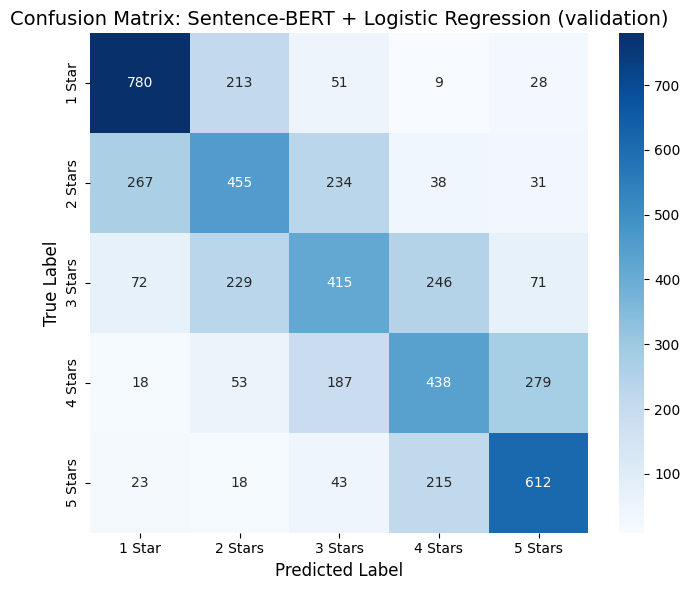

--- VALIDATION Performance ---
Accuracy: 0.5373
Macro-F1: 0.5330

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.67      0.72      0.70      1081
           2       0.47      0.44      0.46      1025
           3       0.45      0.40      0.42      1033
           4       0.46      0.45      0.46       975
           5       0.60      0.67      0.63       911

    accuracy                           0.54      5025
   macro avg       0.53      0.54      0.53      5025
weighted avg       0.53      0.54      0.53      5025

--- Confusion Matrix (raw) ---
[[780 213  51   9  28]
 [267 455 234  38  31]
 [ 72 229 415 246  71]
 [ 18  53 187 438 279]
 [ 23  18  43 215 612]]

Evaluating on test set ...


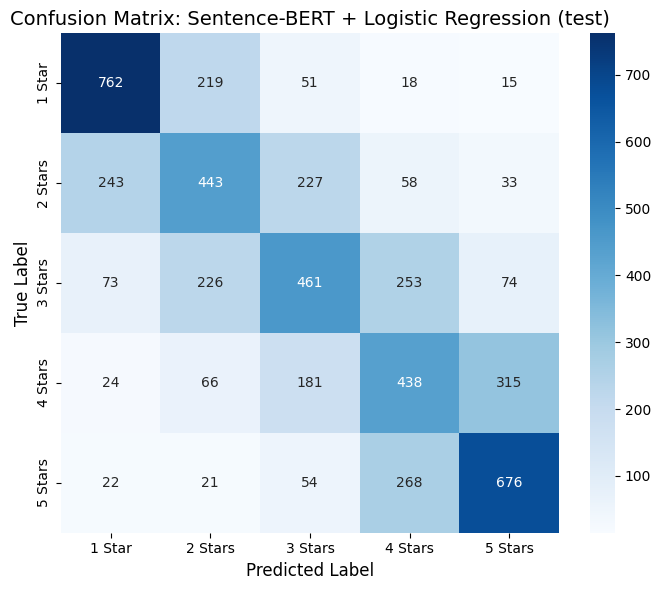

--- TEST Performance ---
Accuracy: 0.5325
Macro-F1: 0.5289

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.68      0.72      0.70      1065
           2       0.45      0.44      0.45      1004
           3       0.47      0.42      0.45      1087
           4       0.42      0.43      0.43      1024
           5       0.61      0.65      0.63      1041

    accuracy                           0.53      5221
   macro avg       0.53      0.53      0.53      5221
weighted avg       0.53      0.53      0.53      5221

--- Confusion Matrix (raw) ---
[[762 219  51  18  15]
 [243 443 227  58  33]
 [ 73 226 461 253  74]
 [ 24  66 181 438 315]
 [ 22  21  54 268 676]]


,split,accuracy,macro_f1,num_samples
0,validation,0.537313,0.533018,5025
1,test,0.532465,0.528877,5221


In [9]:
print("Evaluating on validation set ...")
val_pred = clf.predict(X_val_embed)
val_metrics = evaluate_and_save("validation", y_val, val_pred, result_dir)

print("\nEvaluating on test set ...")
test_pred = clf.predict(X_test_embed)
test_metrics = evaluate_and_save("test", y_test, test_pred, result_dir)

summary_df = pd.DataFrame([val_metrics, test_metrics])
summary_df.to_csv(result_dir / "metrics_summary.csv", index=False)
display(summary_df)